# Machine Learning Pipeline
This notebook contains code for the Machine learning pipeline presented in the Dissertation. Please verify the packages match the once presented in the READ ME before proceeding. 

### Package Imports

In [1]:
import numpy as np
import pandas as pd
import mne
print(mne.__version__)
from pathlib import Path
import matplotlib
%matplotlib inline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier
from lightgbm import LGBMClassifier
from sklearn.feature_selection import RFECV
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.decomposition import PCA
from scipy.stats import spearmanr , pearsonr
import pickle
import shap
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score



1.11.0


In [2]:
import sys
packages = ['numpy', 'pandas', 'mne', 'matplotlib', 'sklearn', 'scipy', 'lightgbm', 'shap']

print(f"Python: {sys.version}\n")
for package in packages:
    module = __import__(package)
    version = getattr(module, '__version__', 'version not found')
    print(f"{package}: {version}")

Python: 3.12.10 (tags/v3.12.10:0cc8128, Apr  8 2025, 12:21:36) [MSC v.1943 64 bit (AMD64)]

numpy: 2.0.2
pandas: 2.3.3
mne: 1.11.0
matplotlib: 3.10.0
sklearn: 1.8.0
scipy: 1.16.3
lightgbm: 4.6.0
shap: 0.50.0


### Data Imports

In [4]:
with open("data_loss_mask.pkl", "rb") as f:
    data_loss_mask = pickle.load(f)

print(np.shape(data_loss_mask))
with open("masked_participant_accuracy.pkl", "rb") as f:
    accuracy = pickle.load(f)

print(np.shape(accuracy))

with open("c_final_new_features/mrmr_all_ft_feature_sets.pkl", "rb") as f:
    features_ag = pickle.load(f)

print(np.shape(features_ag))

(21, 21)
(370,)
(370, 40)


In [5]:
data_loss_mask = np.array(data_loss_mask)
accuracy = np.array(accuracy, dtype = int)
puzzle_num = np.tile(np.arange(21),21)[data_loss_mask.reshape(-1)]
participant_num  = np.repeat(np.arange(21),21)[data_loss_mask.reshape(-1)]

In [6]:
puzzle_num

array([ 0,  1,  2,  3,  4,  5,  6,  7, 14, 15, 16, 17, 18, 19, 20,  0,  1,
        2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18,
       19, 20,  1,  2,  4,  5,  6,  7,  8, 10, 11, 12, 13, 16, 17, 18, 19,
       20,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15,
       16, 17, 18, 19, 20,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11,
       12, 13, 14, 15, 16, 17, 18, 19, 20,  0,  1,  2,  3,  4,  5,  6,  7,
        8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,  0,  1,  2,  3,
        4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,
        0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13,
       14, 15, 16, 17, 19, 20,  0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10,
       11, 12, 13, 14, 15, 16, 17, 18, 19, 20,  0,  1,  2,  3,  4,  7,  8,
        9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20,  0,  1,  2,  3, 13,
       14, 17, 20,  0,  1

Code below is made to calculate the baselines as presented in the dissertation. Note, since the baselines have no actual learning, this is done without the need for classifiers.

In [7]:
# Predict all 1s
all_ones = np.ones(len(accuracy), dtype=int)
print("Baseline - Predict all 1s:")
print(f"  Acc: {accuracy_score(accuracy, all_ones):.3f}")
print(f"  Pre: {precision_score(accuracy, all_ones, zero_division=0):.3f}")
print(f"  Rec: {recall_score(accuracy, all_ones, zero_division=0):.3f}")
print(f"  F1:  {f1_score(accuracy, all_ones, zero_division=0):.3f}")

# Predict most common per puzzle
puzzle_preds = np.zeros(len(accuracy), dtype=int)
for puzzle in np.unique(puzzle_num):
    mask = puzzle_num == puzzle
    most_common = np.bincount(accuracy[mask]).argmax()
    puzzle_preds[mask] = most_common

print("\nBaseline - Predict most common per puzzle:")
print(f"  Acc: {accuracy_score(accuracy, puzzle_preds):.3f}")
print(f"  Pre: {precision_score(accuracy, puzzle_preds, zero_division=0):.3f}")
print(f"  Rec: {recall_score(accuracy, puzzle_preds, zero_division=0):.3f}")
print(f"  F1:  {f1_score(accuracy, puzzle_preds, zero_division=0):.3f}")

Baseline - Predict all 1s:
  Acc: 0.530
  Pre: 0.530
  Rec: 1.000
  F1:  0.693

Baseline - Predict most common per puzzle:
  Acc: 0.651
  Pre: 0.675
  Rec: 0.658
  F1:  0.667


Code Below creates the one-hot encoded puzzle information for the PUzzle Informed model

In [8]:
from sklearn.preprocessing import OneHotEncoder


ohe = OneHotEncoder(sparse_output=False)
puzzle_ohe = ohe.fit_transform(puzzle_num.reshape(-1, 1))
print(puzzle_ohe.shape) 
puzzle_ohe

(370, 21)


array([[1., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]])

In [9]:
features_pi = np.hstack([features_ag, puzzle_ohe])
print(features_pi.shape)

(370, 61)


## Training Puzzle Agnostic and Puzzle Informed models

In [10]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()), 
    ("clf", LogisticRegression(penalty="l2",solver="lbfgs",max_iter=1000))])
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf",probability=False))]) #Look into the probability=true thing
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=5,weights="distance"))])
nb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", GaussianNB())])
rf_pipeline = Pipeline([
    ("clf", RandomForestClassifier(n_estimators=300,max_depth=None, random_state=42))])
lgbm_pipeline = Pipeline([
    ("clf", LGBMClassifier(objective="binary",n_estimators=100,learning_rate=0.1,num_leaves=31,random_state=42,verbose=-1))])

classifiers = {
    "LR": lr_pipeline,
    "SVM": svm_pipeline,
    "KNN": knn_pipeline,
    "NB": nb_pipeline,
    "RF": rf_pipeline,
    "LGBM": lgbm_pipeline,
}

In [11]:
#Hyperparameter tuning:
param_grids = {
    'LR': {
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__penalty': ['l1', 'l2'],
        'clf__solver': ['liblinear', 'saga']
    },
    'SVM': {
        'clf__C': [0.01, 0.1, 1, 10, 100],  
        'clf__kernel': ['linear', 'rbf', 'poly'],  
        'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],  
        'clf__degree': [2, 3],  
    },
    'KNN': {
        'clf__n_neighbors': [1, 3, 5, 7, 10, 15, 20, 30, 50, 75, 100],  
        'clf__weights': ['uniform', 'distance'],
        'clf__metric': ['euclidean', 'manhattan', 'minkowski'],  
        'clf__p': [1, 2]
    },
    'NB': { 'clf__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    },
    'RF': {
        'clf__n_estimators': [100, 200, 300, 500],  
        'clf__max_depth': [None, 10, 20, 30, 50],  
        'clf__min_samples_split': [2, 5, 10, 20], 
        'clf__min_samples_leaf': [1, 2, 4],  
        'clf__max_features': ['sqrt', 'log2'],
    },
    'LGBM': {
        'clf__num_leaves': [31, 50, 100],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__n_estimators': [100, 200, 300, 500,1000]
    }
}

para_num = {
    "LR": 16,
    "SVM": 70,
    "KNN": 50,
    "NB": 5,
    "RF": 80,
    "LGBM": 10,
}

Code below trains the Puzzle Agnostic and Puzzle Informed models across all the datasets. Note, this code takes hours to run on all datasets due to it being a very rigours process. 

In [ ]:
from sklearn.model_selection import LeaveOneGroupOut, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')
model_type = "agnostic"  # agnostic or informed
n_repeats = 10


#feature_sets = [ "mrmr_all_ft_feature_sets", "mrmr_first_feature_sets", "mrmr_last_feature_sets", "mrmr_full_ft_feature_sets", "mrmr_until_ft_feature_sets"]
feature_sets = [ "mrmr_full_ft_feature_sets","mrmr_until_ft_feature_sets"]

for feature_set in feature_sets:
    print(f"Start: {feature_set}")
    with open(f"c_final_new_features/{feature_set}.pkl", "rb") as f:
        features_ag = pickle.load(f)
        features = features_ag
        if model_type == "informed":
            ohe = OneHotEncoder(sparse_output=False)
            puzzle_ohe = ohe.fit_transform(puzzle_num.reshape(-1, 1))
            features = np.hstack([features_ag, puzzle_ohe])
        


    if isinstance(features, pd.DataFrame):
        features = features.to_numpy()

    repeat_results = {name: {'accuracy': [], 'precision': [], 'recall': [], 'f1': []} for name in classifiers}

    for repeat in range(n_repeats):
        print(f"\nRepeat {repeat+1}/{n_repeats}")
        participants = np.unique(participant_num)
        np.random.seed(repeat)
        np.random.shuffle(participants)
        fold_splits = participants.reshape(10, 2)

        all_preds = {name: {'y_true': [], 'y_pred': []} for name in classifiers}

        for fold, test_participants in enumerate(fold_splits):
            test_mask = np.isin(participant_num, test_participants)
            train_mask = ~test_mask

            X_train, X_test = features[train_mask], features[test_mask]
            y_train, y_test = accuracy[train_mask], accuracy[test_mask]
            groups_train = participant_num[train_mask]
            print(f"  Fold {fold+1}/10")

            for name in classifiers:
                inner_logo = LeaveOneGroupOut()
                search = RandomizedSearchCV(
                    clone(classifiers[name]),
                    param_distributions=param_grids[name],
                    n_iter=para_num[name],
                    cv=inner_logo,
                    scoring='accuracy',
                    n_jobs=-1,
                    random_state=42
                )
                with warnings.catch_warnings():
                    warnings.simplefilter("ignore")
                    search.fit(X_train, y_train, groups=groups_train)
                    y_pred = search.best_estimator_.predict(X_test)

                all_preds[name]['y_true'].extend(y_test)
                all_preds[name]['y_pred'].extend(y_pred)

        for name in classifiers:
            y_true = np.array(all_preds[name]['y_true'])
            y_pred = np.array(all_preds[name]['y_pred'])
            repeat_results[name]['accuracy'].append(accuracy_score(y_true, y_pred))
            repeat_results[name]['precision'].append(precision_score(y_true, y_pred, zero_division=0))
            repeat_results[name]['recall'].append(recall_score(y_true, y_pred, zero_division=0))
            repeat_results[name]['f1'].append(f1_score(y_true, y_pred, zero_division=0))

    print(f"\nResults [{model_type}] (10 repeats x 10-fold, 2 participants per fold):")
    print("=" * 52)
    for name in classifiers:
        acc = repeat_results[name]['accuracy']
        pre = repeat_results[name]['precision']
        rec = repeat_results[name]['recall']
        f1  = repeat_results[name]['f1']
        print(f"{name}: \n"
            f"  Acc: {np.mean(acc):.3f} ± {np.std(acc):.3f} \n"
            f"  Pre: {np.mean(pre):.3f} ± {np.std(pre):.3f} \n"
            f"  Rec: {np.mean(rec):.3f} ± {np.std(rec):.3f} \n"
            f"  F1:  {np.mean(f1):.3f} ± {np.std(f1):.3f}")
        print("-" * 52)

    with open(f"ml_results/{feature_set}_agnostic_result.pkl", "wb") as f:
        pickle.dump(repeat_results, f)
print("All done")

Start: mrmr_full_ft_feature_sets

Repeat 1/10
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10
  Fold 6/10
  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

Repeat 2/10
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10
  Fold 6/10
  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

Repeat 3/10
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10
  Fold 6/10
  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

Repeat 4/10
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10
  Fold 6/10
  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

Repeat 5/10
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10
  Fold 6/10
  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

Repeat 6/10
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10
  Fold 6/10
  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

Repeat 7/10
  Fold 1/10
  Fold 2/10
  Fold 3/10
  Fold 4/10
  Fold 5/10
  Fold 6/10
  Fold 7/10
  Fold 8/10
  Fold 9/10
  Fold 10/10

Repeat 8/10
  Fold 1/10
  Fo

In [8]:

# Load the file
with open(f"ml_results/mrmr_all_ft_feature_sets_agnostic_result.pkl", "rb") as f:
    repeat_results = pickle.load(f)

# Display results
for name in repeat_results:
    acc = repeat_results[name]['accuracy']
    pre = repeat_results[name]['precision']
    rec = repeat_results[name]['recall']
    f1  = repeat_results[name]['f1']
    print(f"{name}: \n"
          f"  Acc: {np.mean(acc):.3f} ± {np.std(acc):.3f} \n"
          f"  Pre: {np.mean(pre):.3f} ± {np.std(pre):.3f} \n"
          f"  Rec: {np.mean(rec):.3f} ± {np.std(rec):.3f} \n"
          f"  F1:  {np.mean(f1):.3f} ± {np.std(f1):.3f}")
    print("-" * 52)

LR: 
  Acc: 0.714 ± 0.013 
  Pre: 0.714 ± 0.011 
  Rec: 0.768 ± 0.021 
  F1:  0.740 ± 0.013
----------------------------------------------------
SVM: 
  Acc: 0.716 ± 0.009 
  Pre: 0.689 ± 0.006 
  Rec: 0.843 ± 0.017 
  F1:  0.759 ± 0.009
----------------------------------------------------
KNN: 
  Acc: 0.694 ± 0.013 
  Pre: 0.667 ± 0.012 
  Rec: 0.844 ± 0.025 
  F1:  0.745 ± 0.011
----------------------------------------------------
NB: 
  Acc: 0.686 ± 0.005 
  Pre: 0.669 ± 0.005 
  Rec: 0.806 ± 0.008 
  F1:  0.731 ± 0.005
----------------------------------------------------
RF: 
  Acc: 0.678 ± 0.010 
  Pre: 0.681 ± 0.010 
  Rec: 0.737 ± 0.015 
  F1:  0.708 ± 0.009
----------------------------------------------------
LGBM: 
  Acc: 0.663 ± 0.018 
  Pre: 0.672 ± 0.017 
  Rec: 0.710 ± 0.023 
  F1:  0.690 ± 0.017
----------------------------------------------------


## Puzzle driven Training
Now onto Puzzle Driven, this is much faster to run and verify if you wish.

In [ ]:
from sklearn.model_selection import RandomizedSearchCV, cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import clone
import warnings
warnings.filterwarnings("ignore")
import numpy as np

feature_sets = [ "mrmr_all_ft_feature_sets", "mrmr_first_feature_sets", "mrmr_last_feature_sets", "mrmr_full_ft_feature_sets", "mrmr_until_ft_feature_sets"]

for feature_set in feature_sets:
    print(f"Start: {feature_set}")
    with open(f"c_final_new_features/{feature_set}.pkl", "rb") as f:
        features = pickle.load(f)

    if isinstance(features, pd.DataFrame):
        features = features.to_numpy()

    puzzle_results = {name: {'accuracy': [], 'precision': [], 'recall': [], 'f1': []} 
                    for name in classifiers}

    for puzzle in range(21):
        if puzzle == 16: # Skips Puzzle 17 due to it only have one correct solve, making CV training impossiable. This is mentioned in the Dissertation.
            continue    # This is fine since the point of Puzzle driven is not the accuracy but the per puzzle analysis.
        
        print(f"Processing Puzzle {puzzle}...")
        
        puzzle_mask = puzzle_num == puzzle
        puzzle_x = features[puzzle_mask]
        puzzle_y = accuracy[puzzle_mask]
        
        if len(puzzle_x) < 3:
            continue
        
        for name in classifiers:
            # Do hyperparameter tuning on all puzzle data
            search = RandomizedSearchCV(
                clone(classifiers[name]),
                param_distributions=param_grids[name],
                n_iter=10,
                cv=5,  # Use 5-fold CV for tuning
                scoring='accuracy',
                n_jobs=-1,
                random_state=42
            )
            
            with warnings.catch_warnings():
                warnings.simplefilter("ignore")
                search.fit(puzzle_x, puzzle_y)
            
            # Use best score from CV as the metric
            puzzle_results[name]['accuracy'].append(search.best_score_)
            
            # For precision, recall, f1 - refit with best params and get CV predictions
            y_pred = cross_val_predict(search.best_estimator_, puzzle_x, puzzle_y, cv=5)
            puzzle_results[name]['precision'].append(precision_score(puzzle_y, y_pred, zero_division=0))
            puzzle_results[name]['recall'].append(recall_score(puzzle_y, y_pred, zero_division=0))
            puzzle_results[name]['f1'].append(f1_score(puzzle_y, y_pred, zero_division=0))

    print(f"\nPuzzle-Driven Results (tuned on all puzzle data, 5-fold CV):")
    print("=" * 52)
    for name in classifiers:
        acc = puzzle_results[name]['accuracy']
        pre = puzzle_results[name]['precision']
        rec = puzzle_results[name]['recall']
        f1  = puzzle_results[name]['f1']
        print(f"{name}: \n"
            f"  Acc: {np.mean(acc):.3f} ± {np.std(acc):.3f} \n"
            f"  Pre: {np.mean(pre):.3f} ± {np.std(pre):.3f} \n"
            f"  Rec: {np.mean(rec):.3f} ± {np.std(rec):.3f} \n"
            f"  F1:  {np.mean(f1):.3f} ± {np.std(f1):.3f}")
        print("-" * 52)

Start: mrmr_all_ft_feature_sets
Processing Puzzle 0...
Processing Puzzle 1...
Processing Puzzle 2...
Processing Puzzle 3...
Processing Puzzle 4...
Processing Puzzle 5...
Processing Puzzle 6...
Processing Puzzle 7...
Processing Puzzle 8...
Processing Puzzle 9...
Processing Puzzle 10...
Processing Puzzle 11...
Processing Puzzle 12...
Processing Puzzle 13...
Processing Puzzle 14...
Processing Puzzle 15...
Processing Puzzle 17...
Processing Puzzle 18...
Processing Puzzle 19...
Processing Puzzle 20...

Puzzle-Driven Results (tuned on all puzzle data, 5-fold CV):
LR: 
  Acc: 0.769 ± 0.114 
  Pre: 0.689 ± 0.266 
  Rec: 0.767 ± 0.285 
  F1:  0.720 ± 0.266
----------------------------------------------------
SVM: 
  Acc: 0.727 ± 0.103 
  Pre: 0.638 ± 0.340 
  Rec: 0.607 ± 0.375 
  F1:  0.594 ± 0.333
----------------------------------------------------
KNN: 
  Acc: 0.710 ± 0.089 
  Pre: 0.616 ± 0.234 
  Rec: 0.784 ± 0.329 
  F1:  0.678 ± 0.267
----------------------------------------------------

## SHAP Contribution Analysis
This is split into (Puzzle Agnostic and Informed) and (Puzzle Driven)

Use just SVM for Puzzle Agnostic and LR for Puzzle Informed. Note result may slightly differ from the ones presented due to the inbuilt randomness of SHAP sample

In [20]:
lr_pipeline = Pipeline([
    ("scaler", StandardScaler()), 
    ("clf", LogisticRegression(penalty="l2",solver="lbfgs",max_iter=1000))])
svm_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", SVC(kernel="rbf",probability=False))]) 
knn_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", KNeighborsClassifier(n_neighbors=5,weights="distance"))])
nb_pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", GaussianNB())])
rf_pipeline = Pipeline([
    ("clf", RandomForestClassifier(n_estimators=300,max_depth=None, random_state=42))])
lgbm_pipeline = Pipeline([
    ("clf", LGBMClassifier(objective="binary",n_estimators=100,learning_rate=0.1,num_leaves=31,random_state=42,verbose=-1))])

classifiers = {
     #"LR": lr_pipeline,
    "SVM": svm_pipeline,
    # "KNN": knn_pipeline,
    # "NB": nb_pipeline,
    # "RF": rf_pipeline,
    # "LGBM": lgbm_pipeline,
}

In [21]:
#Hyperparameter tuning:
param_grids = {
    'LR': {
        'clf__C': [0.01, 0.1, 1, 10],
        'clf__penalty': ['l1', 'l2'],
        'clf__solver': ['liblinear', 'saga']
    },
    'SVM': {
        'clf__C': [0.01, 0.1, 1, 10, 100],  
        'clf__kernel': ['linear', 'rbf', 'poly'],  
        'clf__gamma': ['scale', 'auto', 0.001, 0.01, 0.1],  
        'clf__degree': [2, 3],  
    },
    'KNN': {
        'clf__n_neighbors': [1, 3, 5, 7, 10, 15, 20, 30, 50, 75, 100],  
        'clf__weights': ['uniform', 'distance'],
        'clf__metric': ['euclidean', 'manhattan', 'minkowski'],  
        'clf__p': [1, 2]
    },
    'NB': { 'clf__var_smoothing': [1e-9, 1e-8, 1e-7, 1e-6, 1e-5]
    },
    'RF': {
        'clf__n_estimators': [100, 200, 300, 500],  
        'clf__max_depth': [None, 10, 20, 30, 50],  
        'clf__min_samples_split': [2, 5, 10, 20], 
        'clf__min_samples_leaf': [1, 2, 4],  
        'clf__max_features': ['sqrt', 'log2'],
    },
    'LGBM': {
        'clf__num_leaves': [31, 50, 100],
        'clf__learning_rate': [0.01, 0.05, 0.1],
        'clf__n_estimators': [100, 200, 300, 500,1000]
    }
}

para_num = {
 #    "LR": 16,
    "SVM": 70,
#     "KNN": 50,
#     "NB": 5,
#     "RF": 80,
#     "LGBM": 10,
}

SVM best params: {'clf__kernel': 'rbf', 'clf__gamma': 0.001, 'clf__degree': 3, 'clf__C': 1}

SHAP for SVM


  0%|          | 0/370 [00:00<?, ?it/s]

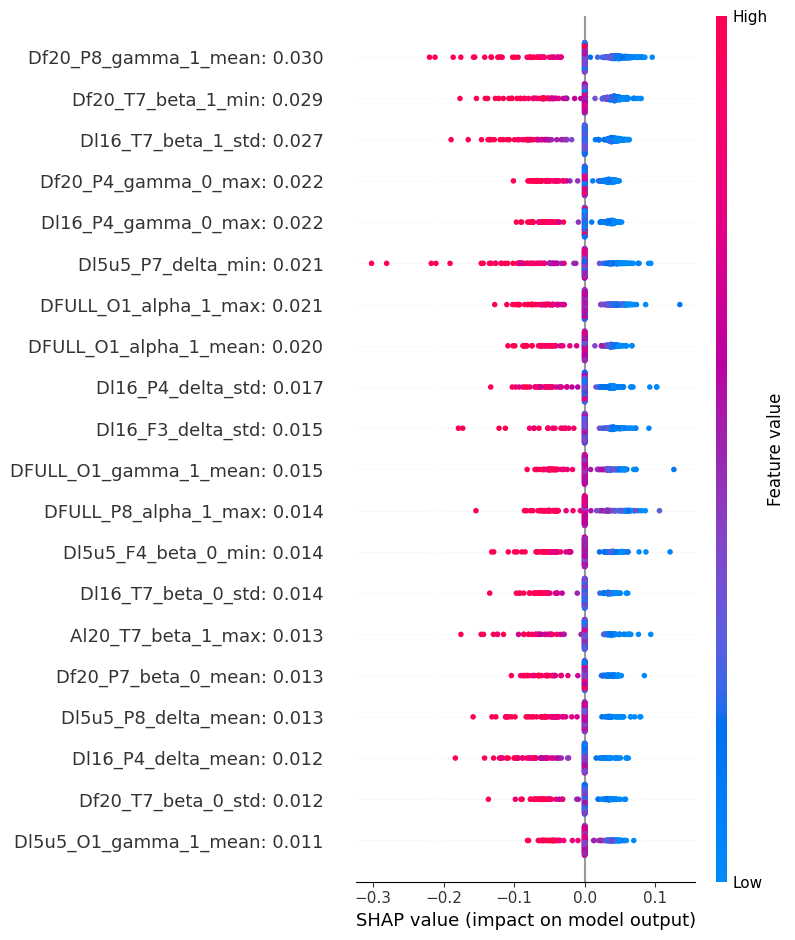

In [22]:
from sklearn.model_selection import LeaveOneGroupOut, RandomizedSearchCV
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.base import clone
import warnings
warnings.filterwarnings('ignore', category=UserWarning, module='lightgbm')
model_type = "agnostic"  # agnostic or informed

with open("c_final_new_features/mrmr_all_ft_feature_sets.pkl", "rb") as f:
    features_ag = pickle.load(f)
ohe = OneHotEncoder(sparse_output=False)
puzzle_ohe = ohe.fit_transform(puzzle_num.reshape(-1, 1))
features_pi = np.hstack([features_ag, puzzle_ohe])

if model_type == "agnostic":
    features = features_ag
elif model_type == "informed":
    features = features_pi


if isinstance(features, pd.DataFrame):
    features = features.to_numpy()


# Train final models on all data
final_models = {}
for name in classifiers:
    inner_logo = LeaveOneGroupOut()
    search = RandomizedSearchCV(
        clone(classifiers[name]),
        param_distributions=param_grids[name],
        n_iter=para_num[name],
        cv=inner_logo,
        scoring='accuracy',
        n_jobs=-1,
        random_state=42
    )
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        search.fit(features, accuracy, groups=participant_num)
    final_models[name] = search.best_estimator_
    print(f"{name} best params: {search.best_params_}")


feature_names = features_ag.columns.tolist() if hasattr(features_ag, 'columns') else [f"feature_{i}" for i in range(features.shape[1])]
if model_type == "informed":
    feature_names = feature_names + [f"Puzzle {i+1}" for i in range(21)]
 

for name, model in final_models.items():
    print(f"\nSHAP for {name}")
    clf = model.named_steps['clf']
    
    # transform features through pipeline steps before clf
    X_transformed = features.copy()
    for step_name, step in model.steps[:-1]:
        X_transformed = step.transform(X_transformed)

    if name == 'LR':
        explainer = shap.LinearExplainer(clf, X_transformed)
        shap_values = explainer.shap_values(X_transformed)
    elif name in ['RF', 'LGBM']:
        explainer = shap.TreeExplainer(clf)
        shap_values = explainer.shap_values(X_transformed)
        if isinstance(shap_values, list):  
            shap_values = shap_values[1]
    else:  # SVM
        explainer = shap.KernelExplainer(clf.predict_proba if hasattr(clf, 'predict_proba') else clf.predict, 
                                          shap.sample(X_transformed,50))
        shap_values = explainer.shap_values(X_transformed)
        if isinstance(shap_values, list):
            shap_values = shap_values[1]
    
    #create feature names with mean absolute SHAP values
    mean_abs_shap = np.abs(shap_values).mean(axis=0).round(3)
    feature_names_with_values = [
        f"{name}: {value:.3f}" for name, value in zip(feature_names, mean_abs_shap)
    ]
    
    shap.summary_plot(shap_values, X_transformed, 
                      feature_names=feature_names_with_values, 
                      show=True)


The code below is used to format and present the graphs

In [18]:
import re
def name_formatter(s):

    if "Puzzle" in s:
        return s

    replacements = {
        r'delta': r'$\\delta$',
        r'theta': r'$\\theta$',
        r'alpha_0': r'$\\alpha_{0}$',
        r'alpha_1': r'$\\alpha_{1}$',
        r'beta_0': r'$\\beta_{0}$',
        r'beta_1': r'$\\beta_{1}$',
        r'gamma_0': r'$\\gamma_{0}$',
        r'gamma_1': r'$\\gamma_{1}$',
    }
    
    for pattern, replacement in replacements.items():
        s = re.sub(pattern, replacement, s)
    
    sep_s = s.split("_")
    if sep_s[0][0] == "A":
        header = f"(TF) ({sep_s[0][1:]})"
    else:
        header = f"(DF) ({sep_s[0][1:]})"
    
    sep_s[0] = header
    result = " ".join(sep_s)
    return result

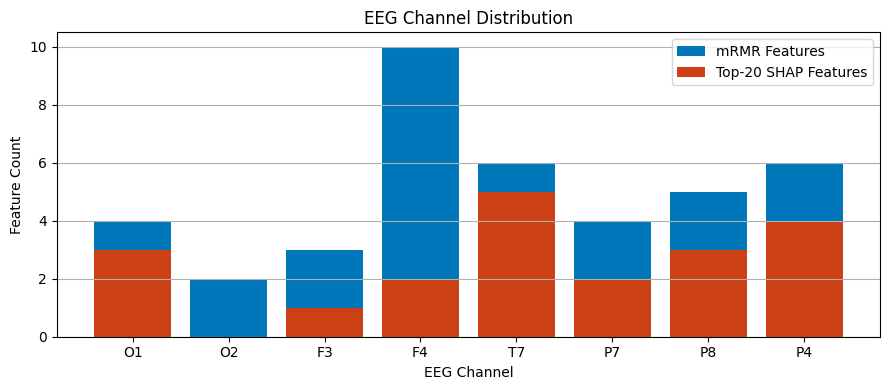

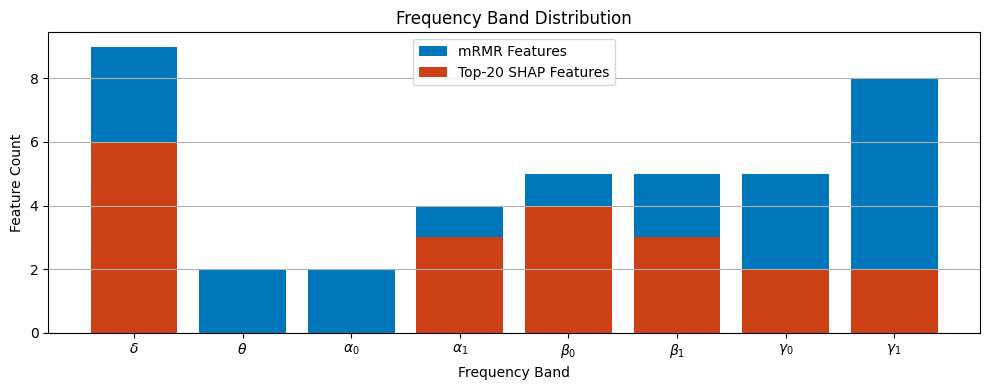

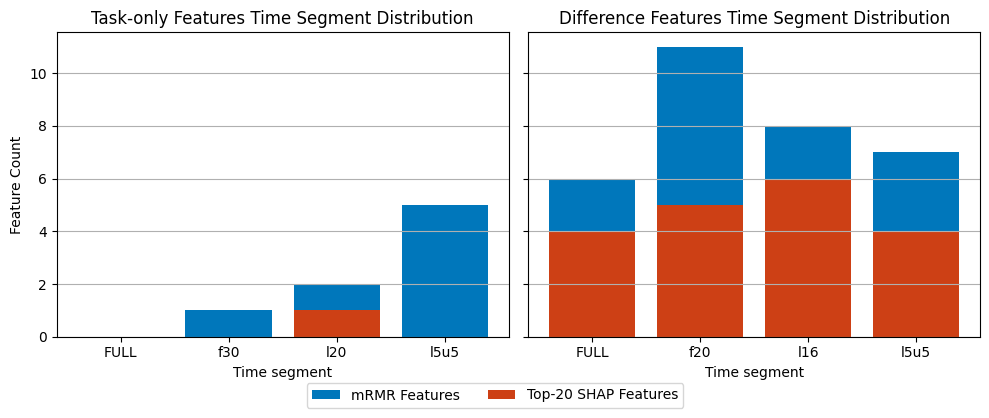

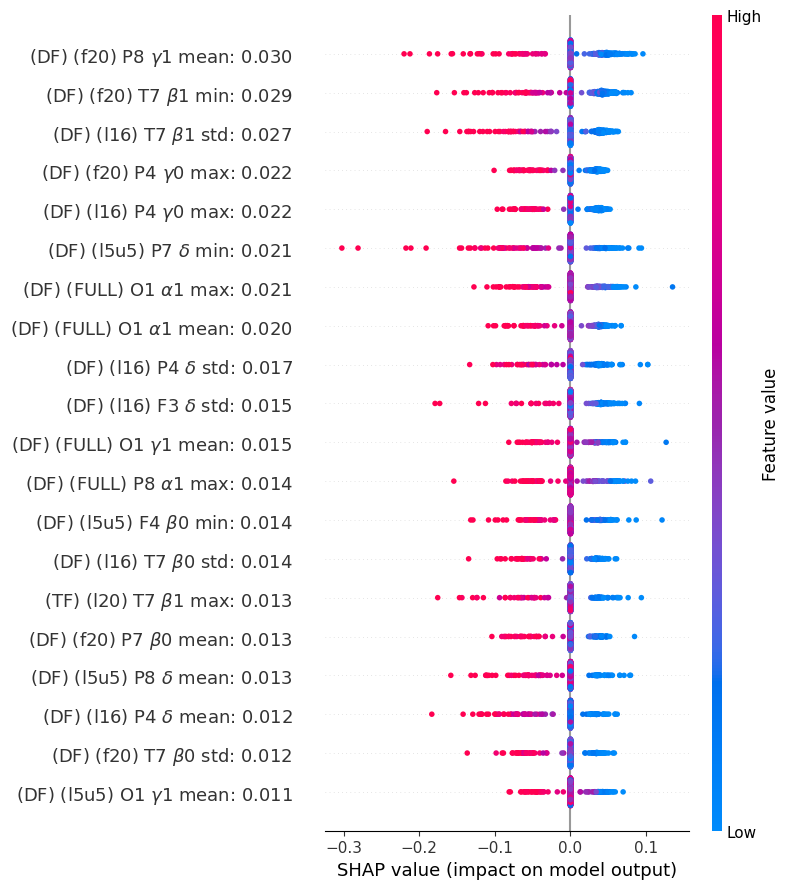

In [23]:

from collections import Counter
import matplotlib.pyplot as plt


mean_abs_shap = np.abs(shap_values).mean(axis=0).round(3)


top_idx = np.argsort(mean_abs_shap)[::-1][:20]

top_features = [
    (feature_names[i], round(mean_abs_shap[i], 3))
    for i in top_idx
]

channels_opt = ["O1", "O2", "F3", "F4", "T7", "P7", "P8", "P4"]
freqbands_opt = ["delta","theta","alpha_0","alpha_1","beta_0","beta_1","gamma_0","gamma_1"]
freqband_labels = [
    r"$\delta$", r"$\theta$",
    r"$\alpha_0$", r"$\alpha_1$",
    r"$\beta_0$", r"$\beta_1$",
    r"$\gamma_0$", r"$\gamma_1$"
]


all_feature_names = feature_names  

all_channel_counts = Counter()
all_freq_counts = Counter()

for feat in all_feature_names:
    for ch in channels_opt:
        if ch in feat:
            all_channel_counts[ch] += 1
    for fb in freqbands_opt:
        if fb in feat:
            all_freq_counts[fb] += 1


top_feature_names = [feature_names[i] for i in top_idx]

shap_channel_counts = Counter()
shap_freq_counts = Counter()

for feat in top_feature_names:
    for ch in channels_opt:
        if ch in feat:
            shap_channel_counts[ch] += 1
    for fb in freqbands_opt:
        if fb in feat:
            shap_freq_counts[fb] += 1

#convert to ordered lists
all_channel_list = [all_channel_counts[ch] for ch in channels_opt]
shap_channel_list = [shap_channel_counts[ch] for ch in channels_opt]

all_freq_list = [all_freq_counts[fb] for fb in freqbands_opt]
shap_freq_list = [shap_freq_counts[fb] for fb in freqbands_opt]

fig1, ax1 = plt.subplots(figsize=(9, 4))
x = np.arange(len(channels_opt))

ax1.bar(x, all_channel_list, color="#0077BB", label="mRMR Features")
ax1.bar(x, shap_channel_list, color="#CD4015", label="Top-20 SHAP Features")

ax1.set_xticks(x)
ax1.set_xticklabels(channels_opt)
ax1.set_xlabel("EEG Channel")
ax1.set_ylabel("Feature Count")
ax1.set_title("EEG Channel Distribution")
ax1.legend()
ax1.grid(True, axis="y")

plt.tight_layout()
plt.savefig("c_EEG_Channel_Distribution_SHAP_vs_All_agnostic.pdf", bbox_inches="tight")
plt.show()

fig2, ax2 = plt.subplots(figsize=(10, 4))
x = np.arange(len(freqbands_opt))

ax2.bar(x, all_freq_list, color="#0077BB", label="mRMR Features")
ax2.bar(x, shap_freq_list, color="#CD4015", label="Top-20 SHAP Features")

ax2.set_xticks(x)
ax2.set_xticklabels(freqband_labels, rotation=0)
ax2.set_xlabel("Frequency Band")
ax2.set_ylabel("Feature Count")
ax2.set_title("Frequency Band Distribution")
ax2.legend()
ax2.grid(True, axis="y")

plt.tight_layout()
plt.savefig("c_Frequency_Distribution_SHAP_vs_All_agnostic.pdf", bbox_inches="tight")
plt.show()


#Time Segment Distribution

timeseg_opt_a = ["FULL", "f30", "l20", "l5u5"]
timeseg_opt_d = ["FULL", "f20", "l16", "l5u5"]


sig_feature_names = top_feature_names


def count_occurrences(feature_list, options):
    return [sum(opt in feat for feat in feature_list) for opt in options]

#split A / D features
a_features = [n for n in all_feature_names if n.startswith("A")]
d_features = [n for n in all_feature_names if n.startswith("D")]

a_sig = [n for n in sig_feature_names if n.startswith("A")]
d_sig = [n for n in sig_feature_names if n.startswith("D")]


all_a = count_occurrences(a_features, timeseg_opt_a)
sig_a = count_occurrences(a_sig, timeseg_opt_a)

all_d = count_occurrences(d_features, timeseg_opt_d)
sig_d = count_occurrences(d_sig, timeseg_opt_d)


fig3, (ax3a, ax3d) = plt.subplots(1, 2, figsize=(10, 4), sharey=True)

# --- A features ---
x_a = np.arange(len(timeseg_opt_a))
ax3a.bar(x_a, all_a, color="#0077BB", label="mRMR Features")
ax3a.bar(x_a, sig_a, color="#CD4015", label="Top-20 SHAP Features")

ax3a.set_xticks(x_a)
ax3a.set_xticklabels(timeseg_opt_a)
ax3a.set_xlabel("Time segment")
ax3a.set_ylabel("Feature Count")
ax3a.set_title("Task-only Features Time Segment Distribution")
ax3a.grid(True, axis="y")

# --- D features ---
x_d = np.arange(len(timeseg_opt_d))
ax3d.bar(x_d, all_d, color="#0077BB", label="mRMR Features")
ax3d.bar(x_d, sig_d, color="#CD4015", label="Top-20 SHAP Features")

ax3d.set_xticks(x_d)
ax3d.set_xticklabels(timeseg_opt_d)
ax3d.set_xlabel("Time segment")
ax3d.set_title("Difference Features Time Segment Distribution")
ax3d.grid(True, axis="y")

handles, labels = ax3a.get_legend_handles_labels()
fig3.legend(handles, labels, loc="lower center", ncol=2, bbox_to_anchor=(0.5, -0.05))

plt.tight_layout()
plt.savefig("c_Time_Segment_Distribution_SHAP_vs_All_agnostic.pdf", bbox_inches="tight")
plt.show()


feature_names_with_values = [
    f"{name_formatter(name)}: {value:.3f}" for name, value in zip(feature_names, mean_abs_shap)
]

shap.summary_plot(shap_values, X_transformed, 
                    feature_names=feature_names_with_values, 
                    show=True, plot_size=[8,9])

Now onto Puzzle Driven SHAP contribution, make sure to just run for LR.

In [ ]:
features = features_ag
if isinstance(features, pd.DataFrame):
    features = features.to_numpy()

puzzle_results = {name: {'accuracy': [], 'precision': [], 'recall': [], 'f1': []} 
                for name in classifiers}



for puzzle in range(21):
    if puzzle == 16: # Skips Puzzle 17 due to it only have one correct solve, making CV training impossiable. This is mentioned in the Dissertation.
        continue
    
    print(f"Processing Puzzle {puzzle}...")
    
    puzzle_mask = puzzle_num == puzzle
    puzzle_x = features[puzzle_mask]
    puzzle_y = accuracy[puzzle_mask]
    
    
    for name in classifiers:
        # Do hyperparameter tuning on all puzzle data
        search = RandomizedSearchCV(
            clone(classifiers[name]),
            param_distributions=param_grids[name],
            n_iter=10,
            cv=5,  
            scoring='accuracy',
            n_jobs=-1,
            random_state=42
        )
        
        with warnings.catch_warnings():
            warnings.simplefilter("ignore")
            search.fit(puzzle_x, puzzle_y)
        final_models = {}
        final_models[name] = search.best_estimator_
        print(f"{name} best params: {search.best_params_}")


    feature_names = features_ag.columns.tolist() if hasattr(features_ag, 'columns') else [f"feature_{i}" for i in range(features.shape[1])]
    
    for name, model in final_models.items():
        #print(f"\nSHAP for {name}")
        clf = model.named_steps['clf']
        
        #Transform features through pipeline steps before clf
        X_transformed = features.copy()
        for step_name, step in model.steps[:-1]:
            X_transformed = step.transform(X_transformed)

        if name == 'LR':
            explainer = shap.LinearExplainer(clf, X_transformed)
            shap_values = explainer.shap_values(X_transformed)
        elif name in ['RF', 'LGBM']:
            explainer = shap.TreeExplainer(clf)
            shap_values = explainer.shap_values(X_transformed)
            if isinstance(shap_values, list):  
                shap_values = shap_values[1]
        else:  # SVM
            explainer = shap.KernelExplainer(clf.predict_proba if hasattr(clf, 'predict_proba') else clf.predict, 
                                            shap.sample(X_transformed,50))
            shap_values = explainer.shap_values(X_transformed)
            if isinstance(shap_values, list):
                shap_values = shap_values[1]
        
        #create feature names with mean absolute SHAP values
        mean_abs_shap = np.abs(shap_values).mean(axis=0).round(3)
        top_idx = np.argsort(mean_abs_shap)[::-1][:5]

        top_features = [
            (name_formatter(feature_names[i]), round(mean_abs_shap[i], 3))
            for i in top_idx
        ]
        for rank, (name, value) in enumerate(top_features, 1):
            print(f"{name:<40} : {value:>6.3f}")
        

Processing Puzzle 0...
LR best params: {'clf__solver': 'liblinear', 'clf__penalty': 'l2', 'clf__C': 0.01}
(DF) (l5u5) F4 $\beta {0}$ min           :  0.046
(DF) (f20) F4 $\gamma {0}$ min           :  0.044
(TF) (l20) T7 $\beta {1}$ max            :  0.041
(DF) (FULL) P4 $\gamma {1}$ min          :  0.034
(DF) (l16) F4 $\gamma {1}$ min           :  0.032
Processing Puzzle 1...
LR best params: {'clf__solver': 'liblinear', 'clf__penalty': 'l2', 'clf__C': 0.01}
(DF) (FULL) F4 $\gamma {1}$ min          :  0.049
(DF) (f20) T7 $\beta {1}$ min            :  0.037
(DF) (l5u5) F4 $\delta$ mean             :  0.035
(TF) (l5u5) F4 $\theta$ min              :  0.031
(TF) (l5u5) P7 $\delta$ min              :  0.030
Processing Puzzle 2...
LR best params: {'clf__solver': 'saga', 'clf__penalty': 'l1', 'clf__C': 1}
(TF) (f30) T7 $\alpha {0}$ max           :  0.459
(DF) (FULL) P4 $\gamma {1}$ min          :  0.437
(DF) (l5u5) P7 $\beta {1}$ std           :  0.406
(TF) (l20) T7 $\beta {1}$ max           